In [1]:
# importing libraries
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt
import ast 
import seaborn as sns 

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

def clean_list(lists):
    if pd.notna(lists):
        return ast.literal_eval(lists)
df['job_skills'] = df['job_skills'].apply(clean_list)

/opt/anaconda3/envs/python_da/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_US = df[df['job_country'] == 'United States']

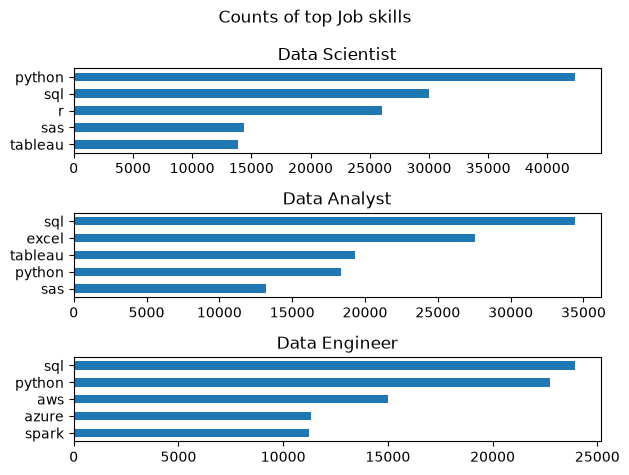

In [28]:
df_skills = df_US.explode('job_skills')
df_count = df_skills.groupby(['job_title_short', 'job_skills']).size().reset_index(name= 'Count')
df_count.sort_values(by= 'Count', ascending=False, inplace= True)
job_list = df_count['job_title_short'].unique().tolist()
title = job_list[:3]
fig,ax = plt.subplots(len(title), 1)
for i, job in enumerate(title):
    df_plot = df_count[df_count['job_title_short'] == job].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='Count', ax=ax[i], title = job, legend = False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
fig.suptitle('Counts of top Job skills')
fig.tight_layout()
plt.show()

In [ ]:
df_total_jobs = df_US['job_title_short'].value_counts().reset_index(name= 'Total Jobs')
df_percentage = pd.merge(df_count, df_total_jobs, how= 'left', on='job_title_short')
df_percentage['Percentage'] = df_percentage['Count'] * 100 / df_percentage['Total Jobs']


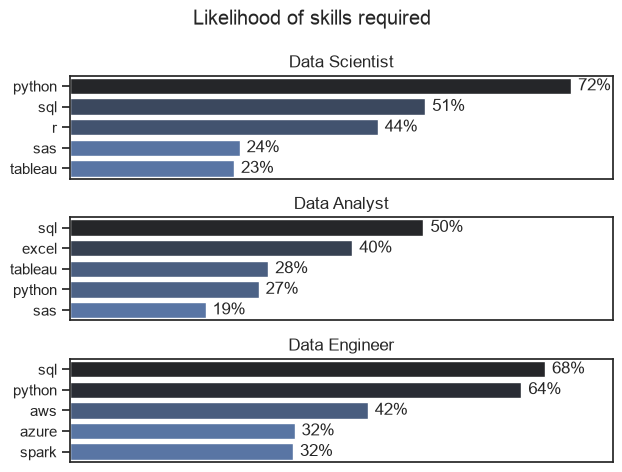

In [66]:
job_list = df_percentage['job_title_short'].unique().tolist()
title = job_list[:3]
sns.set_theme(style='ticks')
fig,ax = plt.subplots(len(title), 1)
for i, job in enumerate(title):
    df_plot_percentage = df_percentage[df_percentage['job_title_short'] == job].head(5)
    sns.barplot(data=df_plot_percentage, x='Percentage', y='job_skills', ax=ax[i],legend=False, hue= 'Percentage', palette='dark:b_r')
    ax[i].set_title(job)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0, 78)
    ax[i].set_xticks([])
    for n,v in enumerate(df_plot_percentage['Percentage']):
        ax[i].text(v+1, n, f'{int(v)}%', va= 'center')

fig.suptitle('Likelihood of skills required')
fig.tight_layout()
plt.show()

In [ ]:
df_plot_percentage

,job_title_short,job_skills,Count,Total Jobs,Percentage
5,Data Engineer,sql,23958,35080,68.295325
6,Data Engineer,python,22762,35080,64.885975
9,Data Engineer,aws,15018,35080,42.810718
15,Data Engineer,azure,11321,35080,32.271950
16,Data Engineer,spark,11242,35080,32.046750
